___

# <font color= #99C8F5> **Autoencoder for CIFAR-10 Generation** </font>
#### <font color= #2E9AFE> `Deep Learning`</font>
<Strong> Sofía Maldonado, Óscar Josué Rocha & Viviana Toledo </Strong>

_17/02/2026._

___

# <font color= #99C8F5> **Introduction** </font>

Autoencoders are a type of neural network made up of two parts: first, an **encoder** that encodes input data down to a compressed, lower-dimention representation (***latent space***). Then, a **decoder** reconstructs the input back to its original form, in the best way it can. 

This arquitecture makes autoencoders very useful for image generation purposes: if an encoder can learn to represent a type of data (text, images, or anything else) in a small space, that space can be used to generate new samples based on that information, mimiquing what the training data contained. 

In this exercise, we are using the CIFAR-10 dataset [1] to train a full autoencoder network that can generate images in the dataset's 10 classes. These classes are:
- Airplanes
- Cars
- Birds
- Cats
- Deer
- Dogs
- Frogs
- Horses
- Ships
- Trucks

---

In [3]:
# General
import numpy as np
import pandas as pd
from keras.datasets import cifar10

# Visualization
import matplotlib.pyplot as plt

# Models
import tensorflow as tf
from tensorflow.python.client import device_lib
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, UpSampling2D
from keras.optimizers import Adam
from keras import Model

In [4]:
print(device_lib.list_local_devices())
print(tf.__version__)
print("Num GPUs Available: ", len(tf.config.experimental.list_physical_devices('GPU')))

[name: "/device:CPU:0"
device_type: "CPU"
memory_limit: 268435456
locality {
}
incarnation: 3956234935807915934
xla_global_id: -1
, name: "/device:GPU:0"
device_type: "GPU"
memory_limit: 4344971264
locality {
  bus_id: 1
  links {
  }
}
incarnation: 12394658682576740518
physical_device_desc: "device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9"
xla_global_id: 416903419
]
2.20.0
Num GPUs Available:  1


I0000 00:00:1771235939.182583    5600 gpu_device.cc:2020] Created device /device:GPU:0 with 4143 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


# <font color= #99C8F5> **Data Loading & Visualization** </font>

In [5]:
# Load Data
(X_train, y_train), (X_test, y_test) = cifar10.load_data()
X_train.shape, X_test.shape, y_train.shape, y_test.shape

/home/vivienne/anaconda3/envs/deep-learning/lib/python3.11/site-packages/keras/src/datasets/cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


((50000, 32, 32, 3), (10000, 32, 32, 3), (50000, 1), (10000, 1))

The CIFAR-10 dataset contains 50K training images and 10K testing images. These images have a size of 32x32 pixels with an RGB channel.

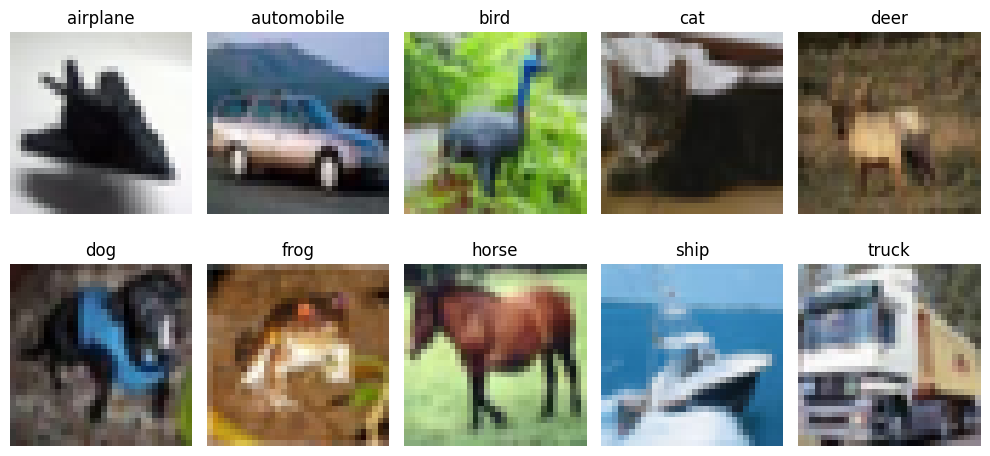

In [6]:
# Flatten labels for visualization
y_train = y_train.flatten()

# Class names
class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

# Create the plot
plt.figure(figsize=(10, 5))
# Select an image for each class
for class_id in range(10):
    index = np.where(y_train == class_id)[0][0]
    # Plot the imaage
    plt.subplot(2, 5, class_id + 1)
    plt.imshow(X_train[index])
    plt.title(class_names[class_id])
    plt.axis('off')

plt.tight_layout()
plt.show()

The images have a low resolution, which makes them highly pixelated. This should be taken into account when evaluating the results of the autoencoder.

# <font color= #99C8F5> **Preprocessing** </font>

The objective of this activity is to build an autoencoder capable of recreating images of the CIFAR-10 dataset. For this reason, data-augmentation techniques would be ill-advised, since the learning and comparison between images would be hindered. Thus, only a normalization will be applied.

In [7]:
# Normalization
X_train = X_train.astype('float32') / 255
X_test = X_test.astype('float32') / 255

In [8]:
X_train.shape, X_test.shape

((50000, 32, 32, 3), (10000, 32, 32, 3))

In [9]:
X_train.min(), X_train.max()

(np.float32(0.0), np.float32(1.0))

# <font color= #99C8F5> **Modeling** </font>

The model architecture will mimic a Convolutional Autoencoder with three levels of compression:

$$
1024_{input}  \rightarrow 256_{h_1} \rightarrow 128_{h_2} \rightarrow 64_{h_3} \rightarrow 32_z \leftarrow 64_{h_3} \leftarrow 128_{h_2} \leftarrow 256_{h_1} \leftarrow 1024_{output}
$$

The construction of the neural network using Keras was made based on articles [2] and [3] (check references below)

In [10]:
num_labels = 10
input_shape = (32,32,3) #1024

In [11]:
model = Sequential(name='Convolutional_AE')

# Encoder
model.add(Conv2D(256, input_shape=input_shape ,kernel_size=5, activation='relu', padding='same'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(128, kernel_size=3, activation='relu', padding='same'))
model.add(MaxPooling2D(pool_size=(1,2)))

model.add(Conv2D(64, kernel_size=3, activation='relu', padding='same'))
model.add(MaxPooling2D(pool_size=(2,1)))

model.add(Conv2D(32, kernel_size=3, activation='relu', padding='same'))
model.add(MaxPooling2D(pool_size=(1,2)))

# Decoder
model.add(Conv2D(32, kernel_size=3, activation='relu', padding='same'))
model.add(UpSampling2D(size=(1,2)))

model.add(Conv2D(64, kernel_size=3, activation='relu', padding='same'))
model.add(UpSampling2D(size=(2,1)))

model.add(Conv2D(128, kernel_size=3, activation='relu', padding='same'))
model.add(UpSampling2D(size=(1,2)))

model.add(Conv2D(256, kernel_size=5, activation='relu', padding='same'))
model.add(UpSampling2D(size=(2,2)))

model.add(Conv2D(3, kernel_size=3, activation='sigmoid', padding='same'))

model.summary()

/home/vivienne/anaconda3/envs/deep-learning/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1771235940.945589    5600 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4143 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Model: "Convolutional_AE"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 256)    │        19,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 128)    │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 8, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 8, 64)      │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 32)       │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 4, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 4, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 16, 8, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 8, 128)     │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 256)    │       819,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_3 (UpSampling2D)  │ (None, 32, 32, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 3)      │         6,915 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,334,723 (5.09 MB)

 Trainable params: 1,334,723 (5.09 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
optimizer = Adam(learning_rate=1e-)

In [13]:
model.compile(
    optimizer=optimizer,
    loss='binary_crossentropy'
)

In [14]:
model.fit(X_train, X_train, batch_size=256, epochs=20, validation_data=(X_test, X_test))

Epoch 1/20


2026-02-16 03:59:05.451995: I external/local_xla/xla/service/service.cc:163] XLA service 0x7183600129c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-02-16 03:59:05.452011: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4050 Laptop GPU, Compute Capability 8.9
2026-02-16 03:59:05.519463: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-02-16 03:59:05.832163: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91900


  1/196 ━━━━━━━━━━━━━━━━━━━━ 47:04 14s/step - loss: 0.6933

I0000 00:00:1771235958.073831    5682 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - loss: 0.6860

2026-02-16 03:59:44.757292: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 2.08GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.


196/196 ━━━━━━━━━━━━━━━━━━━━ 45s 158ms/step - loss: 0.6688 - val_loss: 0.6295
Epoch 2/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 21s 107ms/step - loss: 0.6160 - val_loss: 0.6078
Epoch 3/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 21s 107ms/step - loss: 0.6016 - val_loss: 0.5981
Epoch 4/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 22s 113ms/step - loss: 0.5948 - val_loss: 0.5935
Epoch 5/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 21s 109ms/step - loss: 0.5911 - val_loss: 0.5904
Epoch 6/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 22s 111ms/step - loss: 0.5885 - val_loss: 0.5881
Epoch 7/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 21s 109ms/step - loss: 0.5864 - val_loss: 0.5862
Epoch 8/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 22s 110ms/step - loss: 0.5847 - val_loss: 0.5847
Epoch 9/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 22s 111ms/step - loss: 0.5832 - val_loss: 0.5834
Epoch 10/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 21s 109ms/step - loss: 0.5821 - val_loss: 0.5825
Epoch 11/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 22s 112ms/step - loss: 0.5812 - val_loss: 0.5815
Epoch 12/20
196/196 ━━━━━━━━━━

In [15]:
preds = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step


In [16]:
preds.min(), preds.max()

(np.float32(0.0009004612), np.float32(0.9940128))

Helper function for displaying an example image and how the full Autoencoder reconstructs it.

In [17]:
def display(array1, array2):
    """Displays ten random images from each array."""
    n = 10
    indices = np.random.randint(len(array1), size=n)
    images1 = array1[indices, :]
    images2 = array2[indices, :]

    plt.figure(figsize=(20, 4))
    for i, (image1, image2) in enumerate(zip(images1, images2)):
        ax = plt.subplot(2, n, i + 1)
        plt.imshow(image1.reshape(32, 32, 3))
        plt.gray()
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)

        ax = plt.subplot(2, n, i + 1 + n)
        plt.imshow(image2.reshape(32, 32, 3))
        plt.gray()
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)

    plt.show()


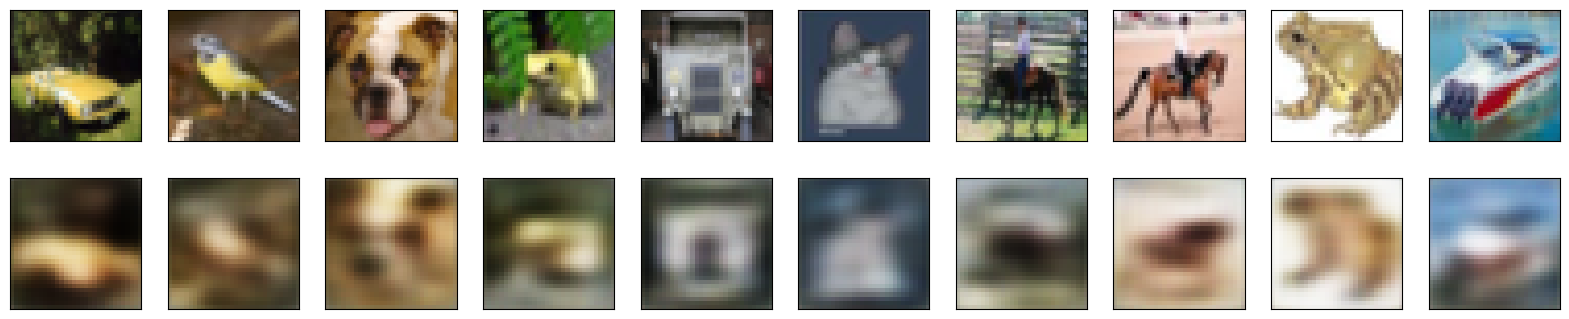

In [18]:
display(X_test, preds)

The images appear to be blurry for now, will update if we have better results

# Bibliography and References

[1] Krizhevsky, A. (2009). Learning Multiple Layers of Features from Tiny Images. **University of Toronto**. https://www.cs.toronto.edu/~kriz/learning-features-2009-TR.pdf

[2] Valdarrama, S. (2021) Convolutional autoencoder for image denoising. **Keras**. https://keras.io/examples/vision/autoencoder/

[3] Chollet, F. (2016) Building Autoencoders in Keras. **The Keras Blog**. https://blog.keras.io/building-autoencoders-in-keras.html 

Potential readings to reduce blur. It's the L2 / MSE:

https://arxiv.org/pdf/2304.05939

https://arxiv.org/pdf/1603.08155

(Stack Overflow) https://stackoverflow.com/questions/58793577/pytorch-convolutional-autoencoder-output-is-blurry-how-to-improve-it

https://www.geeksforgeeks.org/deep-learning/perceptual-autoencoder-enhancing-image-reconstruction-with-deep-learning/